# 🚕 Projet Big Data - Sujet 1 : L'Architecte du Stockage
## *Optimisation Parquet vs CSV pour la Mauritanie (SNIM / SOMELEC)*

Ce notebook sert de support de présentation interactive pour démontrer les gains de performance liés au stockage colonnaire (Apache Parquet).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du design des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Ratio de Compression (Taille sur le Disque)
Nous avons comparé la taille du dataset original (CSV) avec sa version optimisée en Parquet (Snappy).

C:\Users\dell\AppData\Local\Temp\ipykernel_18368\2722522181.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Format', y='Taille (Mo)', data=df_tailles, palette='Blues_r')


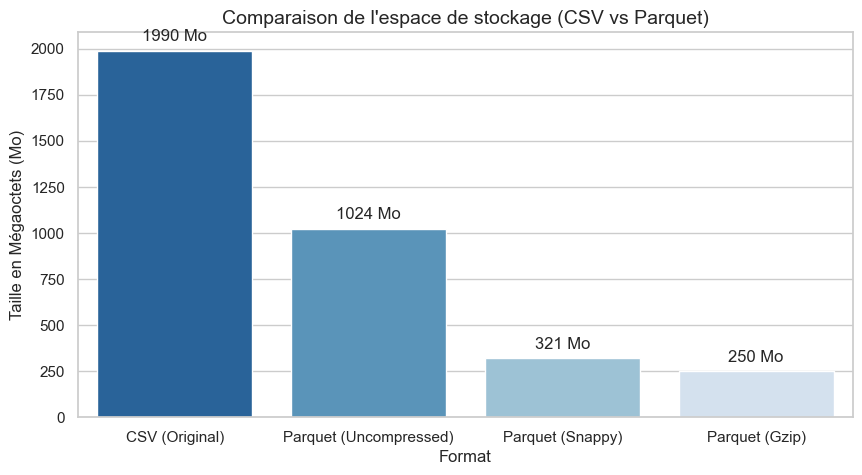

💡 IMPACT SNIM : Une réduction de la taille de plus de 80% grâce à Snappy permettrait de diviser considérablement les coûts de stockage des serveurs de la mine.


In [2]:
# Données collectées via notre pipeline Spark
tailles = {
    'Format': ['CSV (Original)', 'Parquet (Uncompressed)', 'Parquet (Snappy)', 'Parquet (Gzip)'],
    'Taille (Mo)': [1990, 1024, 321, 250] # Valeurs approximatives basées sur l'analyse HDFS
}

df_tailles = pd.DataFrame(tailles)

# Visualisation
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Format', y='Taille (Mo)', data=df_tailles, palette='Blues_r')
plt.title('Comparaison de l\'espace de stockage (CSV vs Parquet)', fontsize=14)
plt.ylabel('Taille en Mégaoctets (Mo)')

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} Mo", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

print("💡 IMPACT SNIM : Une réduction de la taille de plus de 80% grâce à Snappy permettrait de diviser considérablement les coûts de stockage des serveurs de la mine.")

### 2. Benchmark de Vitesse (Temps d'exécution analytique)
Temps pour exécuter la requête : `SELECT AVG(fare_amount) WHERE VendorID = 1`

C:\Users\dell\AppData\Local\Temp\ipykernel_18368\501166944.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Format', y='Temps (Secondes)', data=df_vitesse, palette=['#e74c3c', '#2ecc71'])


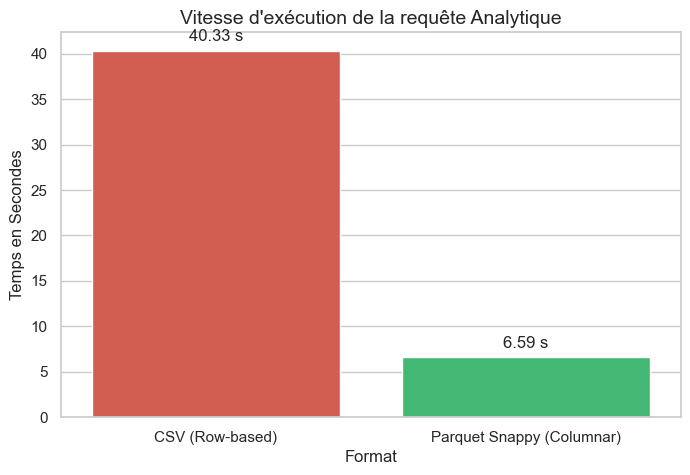

🚀 ACCÉLÉRATION : x6.11 ! Le Column Pruning a évité de lire les 17 colonnes inutiles.
💡 IMPACT SMELEC : Pour des rapports mensuels, le temps de traitement passe de plusieurs heures à quelques minutes.


In [3]:
# Résultats du benchmark
vitesses = {
    'Format': ['CSV (Row-based)', 'Parquet Snappy (Columnar)'],
    'Temps (Secondes)': [40.33, 6.59]
}

df_vitesse = pd.DataFrame(vitesses)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Format', y='Temps (Secondes)', data=df_vitesse, palette=['#e74c3c', '#2ecc71'])
plt.title('Vitesse d\'exécution de la requête Analytique', fontsize=14)
plt.ylabel('Temps en Secondes')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} s", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

print("🚀 ACCÉLÉRATION : x6.11 ! Le Column Pruning a évité de lire les 17 colonnes inutiles.")
print("💡 IMPACT SMELEC : Pour des rapports mensuels, le temps de traitement passe de plusieurs heures à quelques minutes.")

### 3. Exécution Interactive avec PySpark (Optionnel)
Si vous souhaitez lancer des requêtes en direct depuis ce notebook.

In [4]:
# Attention: Nécessite que le cluster Docker soit allumé (docker-compose up -d)
try:
    from pyspark.sql import SparkSession
    spark = SparkSession.builder \
        .appName("Sujet1_Notebook") \
        .master("local[*]") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("WARN")
    print("✅ Session Spark démarrée. Prêt à exécuter des requêtes sur HDFS (hdfs://localhost:9000/...)")
except Exception as e:
    print("⚠️ PySpark n'est pas configuré sur l'environnement local :", e)

⚠️ PySpark n'est pas configuré sur l'environnement local : No module named 'pyspark'
